In [1]:
%pip install -U microlens_submit
%pip install -U RTModel==3.3
%pip install -U jacscanomaly
%pip install -U microjax
%pip install pyAethra

%pip install seaborn

  Using cached microlens_submit-0.17.9-py3-none-any.whl.metadata (10 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
Using cached microlens_submit-0.17.9-py3-none-any.whl (1.1 MB)
Using cached shellingham-1.5.4-py2.py3-none-any.whl (9.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [microlens_submit][microlens_submit]
Note: you may need to restart the kernel to use updated packages.
  Using cached rtmodel-3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (4.5 kB)
  Using cached tabulate-0.10.0-py3-none-any.whl.metadata (40 kB)
  Using cached vbmicrolensing-5.5-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.7 kB)
Using cached rtmodel-3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (1.9 MB)
Using cached vbmicrolensing-5.5-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (1.6 MB)
Using cached tabulate-0.10.0-py3-none-any.whl (39 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [

In [ ]:
# following extra instructions for data download from https://huggingface.co/datasets/RGES-PIT/MachineLearning
%pip install datasets pandas pyarrow duckdb huggingface_hub
#export HF_TOKEN="hf_your_token_here"

  Using cached datasets-5.0.1-py3-none-any.whl.metadata (23 kB)


In [5]:
# system imports
import os
import time
import sys
from pathlib import Path

# data access imports
from huggingface_hub import hf_hub_download
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u

# display imports
from IPython.display import HTML

# multiprocessing imports
import multiprocessing as mp
from multiprocessing.pool import ThreadPool

# data challenge imports
import microlens_submit
#import MulensModel
#import emcee
#from pyLIMA.pyLIMASS import SourceLensProbabilities
import RTModel

# data analysis/visualization imports
import numpy as np
import matplotlib.pyplot as plt

# detection packages
from pyAethra import load_config, load_and_run
from jacscanomaly import CandidateCriteria, Finder, FinderConfig


In [7]:
from datasets import load_dataset
import os

os.environ["HF_TOKEN"] = "your_actual_token_here"

token = os.environ.get("HF_TOKEN")
assert token, "Set HF_TOKEN environment variable first"

dataset_name = "RGES-PIT/MachineLearning"

# Load metadata and epochs tables (which fit easily in RAM)
meta_df = load_dataset(dataset_name, "metadata", split="train", token=token).to_pandas()
epochs_df = load_dataset(dataset_name, "epochs", split="train", token=token).to_pandas()

print(f"Metadata     : {meta_df.shape[0]:,} rows")
print(f"Epochs       : {epochs_df.shape[0]:,} rows")

Metadata     : 377,999 rows
Epochs       : 98,974 rows


In [10]:
meta_df.columns

Index(['name', 'event_id', 'sim_label', 'SubRun', 'Field', 'EventID',
       'final_weight', 'ObsGroup_0_chi2', 't0lens1', 'tE_ref', 'tE_helio',
       'u0lens1', 'rho', 'alpha', 'piE', 'piEE', 'piEN', 'piEll', 'piErp',
       'rE', 'thetaE', 'ra_deg', 'dec_deg', 'galactic_l', 'galactic_b',
       'murel_helio_alpha', 'murel_helio_delta', 'murel_helio_l',
       'murel_helio_b', 'fs_F146', 'fs_F087', 'fs_F213', 'fs2_F146',
       'fs2_F087', 'fs2_F213', 'Lens_F146', 'Lens_F087', 'Lens_F213',
       'Source_F146', 'Source_F087', 'Source_F213', 'Source2_F146',
       'Source2_F087', 'Source2_F213', 'Source_Is_Binary', 'Source_q',
       'Source_combined_logP', 'Source_total_mass', 'Source2_rho', 'Source2_s',
       'Source2_alpha', 'Source2_inc', 'Source2_phase', 'Planet_mass',
       'Planet_q', 'Planet_s', 'Planet_period', 'Planet_semimajoraxis',
       'Planet_orbphase', 'Planet_inclination', 'Lens_Mass', 'Lens_Dist',
       'Lens_Teff', 'Lens_logg', 'Lens_Fe_H', 'Source_Mass', 'Sourc

Wide bound planets

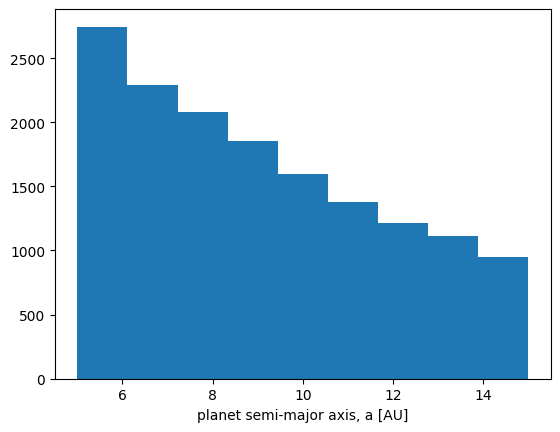

,name,event_id,sim_label,SubRun,Field,EventID,final_weight,ObsGroup_0_chi2,t0lens1,tE_ref,...,Source_Fe_H,Source2_Mass,Source2_Dist,Source2_Teff,Source2_logg,Source2_Fe_H,is_out_of_season,extinction_F146,extinction_F087,extinction_F213
18706,RMDC26_306632,306632,RMDC26_1S2L_ML,0.0,676.0,379.0,0.054843,212.971918,2.462752e+06,4.070668,...,-0.249487,NaN,NaN,NaN,NaN,NaN,False,0.742187,1.852880,0.249147
18712,RMDC26_306728,306728,RMDC26_1S2L_ML,7.0,800.0,406.0,0.025457,3512.102785,2.461441e+06,12.240955,...,0.562349,NaN,NaN,NaN,NaN,NaN,True,0.275844,0.688648,0.092599
18716,RMDC26_306792,306792,RMDC26_1S2L_ML,4.0,677.0,51.0,0.330394,164.298650,2.462733e+06,33.800738,...,-0.216324,NaN,NaN,NaN,NaN,NaN,False,0.527304,1.316420,0.177012
18721,RMDC26_306872,306872,RMDC26_1S2L_ML,8.0,594.0,466.0,0.061780,614820.273316,2.461718e+06,7.724370,...,-0.046650,NaN,NaN,NaN,NaN,NaN,True,1.411985,3.525038,0.473993
18744,RMDC26_307240,307240,RMDC26_1S2L_ML,2.0,126.0,672.0,0.019240,5253.348964,2.461467e+06,9.191137,...,-0.408776,NaN,NaN,NaN,NaN,NaN,False,0.737615,1.841466,0.247612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377967,RMDC26_384503,384503,RMDC26_2S2L_ML,4.0,634.0,15.0,0.028348,203.385045,2.462909e+06,13.337172,...,-0.650853,0.291403,8.807539,3691.8098,4.978471,-0.650853,True,4.067790,10.155287,1.365527
377969,RMDC26_384535,384535,RMDC26_2S2L_ML,9.0,88.0,129.0,0.003574,480.585525,2.461658e+06,93.631589,...,-0.202563,0.158179,11.710305,3301.0117,5.125408,-0.202563,False,0.861075,2.149683,0.289056
377974,RMDC26_384615,384615,RMDC26_2S2L_ML,3.0,799.0,220.0,0.102406,238.061469,2.461807e+06,30.700752,...,-0.737241,0.527495,7.848324,4281.1775,4.741521,-0.737241,True,0.713785,1.781973,0.239612
377993,RMDC26_384919,384919,RMDC26_2S2L_ML,0.0,692.0,56.0,0.000676,52913.559044,2.461520e+06,19.549306,...,0.368688,NaN,NaN,NaN,NaN,NaN,True,4.315334,10.773284,1.448625


In [34]:
wide = meta_df.loc[(meta_df['Planet_semimajoraxis']<=15)&(meta_df['Planet_semimajoraxis']>=5)&(meta_df['Planet_q']>=1e-4)&(meta_df['Planet_q']<=0.033)]
plt.hist(wide['Planet_semimajoraxis'], bins=np.linspace(5,15,10))
plt.xlabel('planet semi-major axis, a [AU]')
plt.show()
wide

In [37]:
wide[['Planet_s','Planet_semimajoraxis','Planet_q','Planet_mass']]

,Planet_s,Planet_semimajoraxis,Planet_q,Planet_mass
18706,2.701138,6.013549,0.000185,0.000018
18712,3.299258,11.742466,0.000639,0.000094
18716,1.689069,7.122461,0.000622,0.000326
18721,3.341677,8.043380,0.000177,0.000091
18744,9.628867,10.641744,0.001271,0.000157
...,...,...,...,...
377967,1.306864,7.425951,0.000412,0.000351
377969,4.068100,11.365737,0.000149,0.000026
377974,2.714064,7.533247,0.002547,0.000818
377993,6.972763,10.318308,0.000587,0.000285


Bona fide FFPs

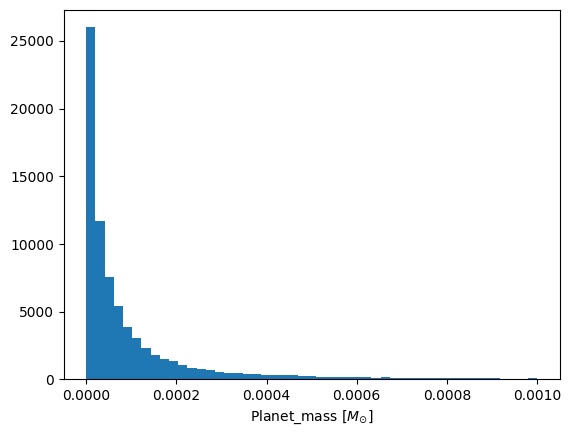

In [21]:
pspl = meta_df.loc[(meta_df['sim_label']=='RMDC26_1S1L_ML')]
#plt.hist(pspl['Lens_Mass'], bins=np.linspace(0,1.2,10))
plt.hist(meta_df.Planet_mass, bins=np.linspace(0, 0.001))
plt.xlabel(r'Planet_mass [$M_{\odot}$]')
plt.show()

In [25]:
meta_df[['Lens_Mass','Planet_mass','Planet_q']].dropna()

,Lens_Mass,Planet_mass,Planet_q
18695,0.477690,0.000054,0.000113
18696,0.218994,0.000010,0.000046
18697,0.480169,0.000130,0.000271
18698,0.173140,0.000291,0.001683
18699,0.639975,0.000002,0.000002
...,...,...,...
377994,0.798287,0.000201,0.000252
377995,0.328890,0.000100,0.000303
377996,0.273385,0.000047,0.000173
377997,0.794123,0.001041,0.001310


In [29]:
ffps = meta_df.loc[(meta_df['sim_label']=='RMDC26_1S1L_ML') & (meta_df['Lens_Mass']<=13*0.000954588)]
ffps

,name,event_id,sim_label,SubRun,Field,EventID,final_weight,ObsGroup_0_chi2,t0lens1,tE_ref,...,Source_Fe_H,Source2_Mass,Source2_Dist,Source2_Teff,Source2_logg,Source2_Fe_H,is_out_of_season,extinction_F146,extinction_F087,extinction_F213
0,RMDC26_003000,3000,RMDC26_1S1L_ML,0.0,633.0,1936.0,0.012366,66.744210,2.462736e+06,3.585315,...,0.319104,NaN,NaN,NaN,NaN,NaN,False,2.061971,5.147735,0.692188
1,RMDC26_003016,3016,RMDC26_1S1L_ML,0.0,718.0,7002.0,0.021194,13124.511426,2.462735e+06,0.214467,...,0.120387,NaN,NaN,NaN,NaN,NaN,False,0.483870,1.207987,0.162431
2,RMDC26_003032,3032,RMDC26_1S1L_ML,0.0,874.0,572.0,0.016154,3438.811691,2.461841e+06,0.051493,...,-0.556216,NaN,NaN,NaN,NaN,NaN,False,0.848105,2.117306,0.284703
3,RMDC26_003048,3048,RMDC26_1S1L_ML,2.0,0.0,4028.0,0.013090,379.330478,2.461504e+06,14.050508,...,0.080757,NaN,NaN,NaN,NaN,NaN,False,3.180586,7.940372,1.067699
7,RMDC26_003112,3112,RMDC26_1S1L_ML,1.0,833.0,7163.0,0.133671,148.670474,2.462927e+06,1.159074,...,0.237952,NaN,NaN,NaN,NaN,NaN,False,1.332737,3.327195,0.447390
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373083,RMDC26_306327,306327,RMDC26_1S1L_ML,0.0,46.0,8781.0,0.003502,9093.691707,2.461489e+06,0.523732,...,0.549583,NaN,NaN,NaN,NaN,NaN,False,0.905255,2.259981,0.303887
373086,RMDC26_306375,306375,RMDC26_1S1L_ML,1.0,676.0,4437.0,0.012477,26835.710390,2.461653e+06,0.071499,...,0.275095,NaN,NaN,NaN,NaN,NaN,False,0.742187,1.852880,0.249147
373087,RMDC26_306391,306391,RMDC26_1S1L_ML,0.0,598.0,7263.0,0.048676,47962.259643,2.462957e+06,1.468066,...,0.211120,NaN,NaN,NaN,NaN,NaN,False,0.449580,1.122381,0.150921
373089,RMDC26_306423,306423,RMDC26_1S1L_ML,1.0,673.0,7090.0,0.014256,437852.475921,2.461505e+06,14.545849,...,-0.449106,NaN,NaN,NaN,NaN,NaN,False,2.590036,6.466057,0.869456
